<a href="https://colab.research.google.com/github/chrishg23-jpg/Community-Development-Framework/blob/main/IntoInfinite003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# HES Transition Core
# -----------------------------

def region_I_step(a, b, n, params):
    """Linear drift toward collapse."""
    a_new = a + params["alpha"] * (1 - a)
    b_new = b + params["beta"]
    n_new = n  # N-mode unchanged in Region I
    return a_new, b_new, n_new

def region_III_step(a, b, n, params):
    """Linear rebound after chaos."""
    a_new = a + params["alpha_rebound"] * (1 - a)
    b_new = b * params["flux_decay"]
    n_new = n  # N-mode fixed after survival
    return a_new, b_new, n_new

# -----------------------------
# Maelstrom Chaos Maps
# -----------------------------

def logistic_map(b, params):
    r = params["logistic_r"]
    return r * b * (1 - b)

def piecewise_map(b, params):
    if b < 0.5:
        return 2 * b
    else:
        return 2 * (1 - b)

def lorenz_map(state, params):
    x, y, z = state
    sigma, rho, beta = params["lor_sigma"], params["lor_rho"], params["lor_beta"]
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return x + dx*0.01, y + dy*0.01, z + dz*0.01


In [4]:
def run_simulation(kind, steps=2000, seed=0):
    np.random.seed(seed)

    # Initial state
    a, b, n = 1.0, 0.01, np.random.uniform(0, 200)
    lor_state = np.array([1.0, 1.0, 1.0])

    # Parameters
    params = dict(
        alpha=0.01,
        beta=0.005,
        B_crit=0.8,
        B_rebound=0.2,
        alpha_rebound=0.02,
        flux_decay=0.95,
        logistic_r=3.9,
        lor_sigma=10.0,
        lor_rho=28.0,
        lor_beta=8/3,
    )

    region = 1
    history = {"a": [], "b": [], "n": [], "region": []}

    for k in range(steps):

        # Region I → II
        if region == 1:
            a, b, n = region_I_step(a, b, n, params)
            if abs(b) >= params["B_crit"]:
                region = 2

        # Region II (chaos)
        elif region == 2:
            a = max(0, a - 0.05)  # collapse of order

            if kind == "logistic":
                b = logistic_map(b, params)

            elif kind == "piecewise":
                b = piecewise_map(b, params)

            elif kind == "lorenz":
                lor_state = lorenz_map(lor_state, params)
                b = lor_state[0] / 30.0  # scaled flux

            # N-mode survival pull
            n += 0.1 * (100 - n)

            # Exit chaos
            if abs(b) <= params["B_rebound"]:
                region = 3

        # Region III
        elif region == 3:
            a, b, n = region_III_step(a, b, n, params)

        # Record
        history["a"].append(a)
        history["b"].append(b)
        history["n"].append(n)
        history["region"].append(region)

    return history


In [ ]:
def run_all():
    results = {}
    for kind in ["logistic", "piecewise", "lorenz"]:
        results[kind] = run_simulation(kind, steps=2000)
    return results

results = run_all()


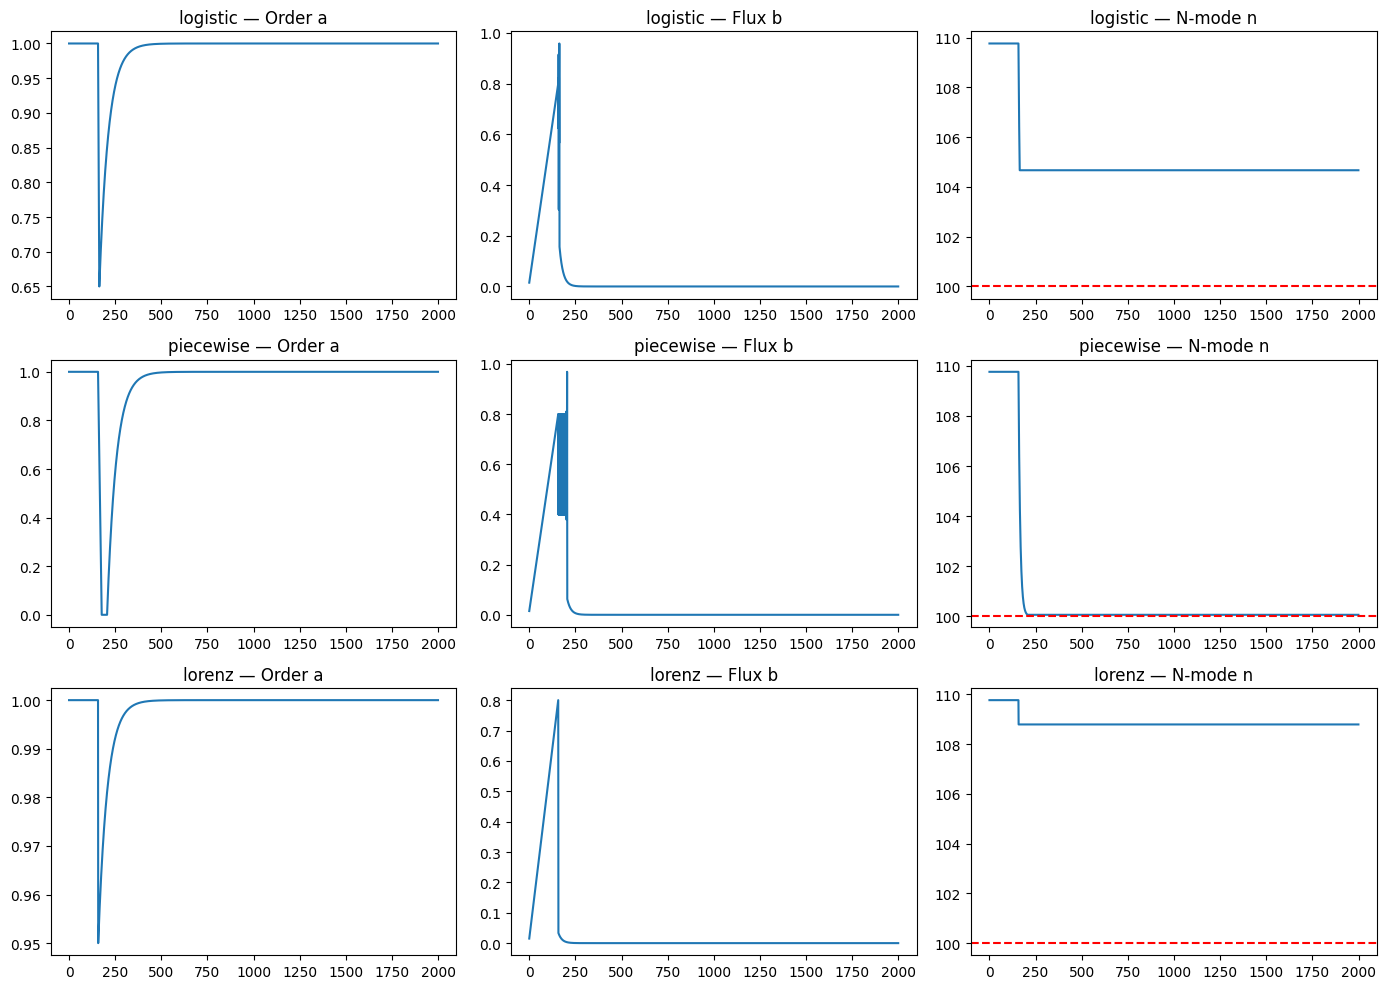

{'logistic': 104.66946952131545,
 'piecewise': 100.05590529473847,
 'lorenz': 108.78643070691845}

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))

for i, kind in enumerate(["logistic", "piecewise", "lorenz"]):
    h = results[kind]

    # Order
    axes[i,0].plot(h["a"])
    axes[i,0].set_title(f"{kind} — Order a")

    # Flux
    axes[i,1].plot(h["b"])
    axes[i,1].set_title(f"{kind} — Flux b")

    # N-mode
    axes[i,2].plot(h["n"])
    axes[i,2].axhline(100, color='red', linestyle='--')
    axes[i,2].set_title(f"{kind} — N-mode n")

plt.tight_layout()
plt.show()

# Extract survival manifold
survival = {k: results[k]["n"][-1] for k in results}
survival


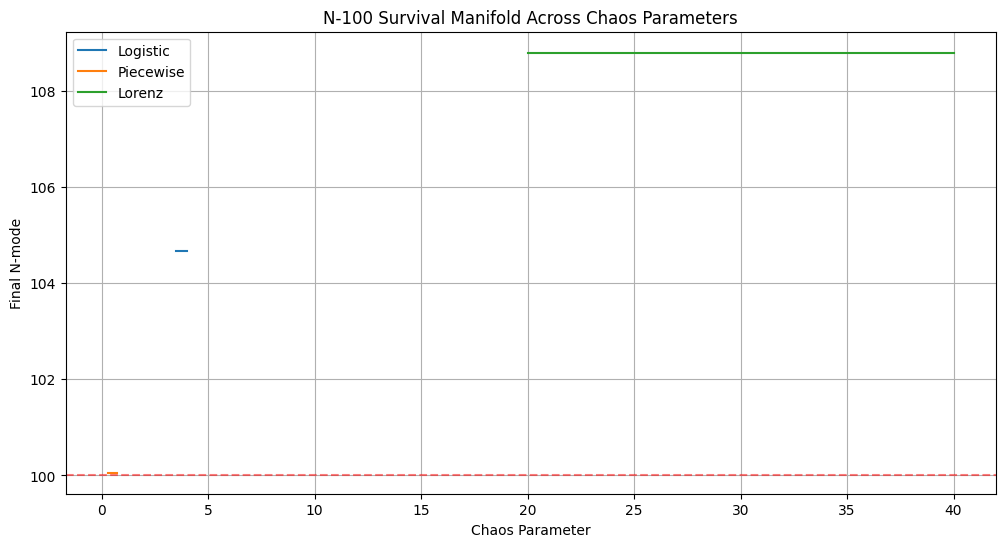

{'logistic': array([104.66946952, 104.66946952, 104.66946952, 104.66946952,
        104.66946952, 104.66946952, 104.66946952, 104.66946952,
        104.66946952, 104.66946952, 104.66946952, 104.66946952,
        104.66946952, 104.66946952, 104.66946952, 104.66946952,
        104.66946952, 104.66946952, 104.66946952, 104.66946952]),
 'piecewise': array([100.05590529, 100.05590529, 100.05590529, 100.05590529,
        100.05590529, 100.05590529, 100.05590529, 100.05590529,
        100.05590529, 100.05590529, 100.05590529, 100.05590529,
        100.05590529, 100.05590529, 100.05590529, 100.05590529,
        100.05590529, 100.05590529, 100.05590529, 100.05590529]),
 'lorenz': array([108.78643071, 108.78643071, 108.78643071, 108.78643071,
        108.78643071, 108.78643071, 108.78643071, 108.78643071,
        108.78643071, 108.78643071, 108.78643071, 108.78643071,
        108.78643071, 108.78643071, 108.78643071, 108.78643071,
        108.78643071, 108.78643071, 108.78643071, 108.78643071])}

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sweep_parameter(kind, param_name, values):
    """Sweep a chaos parameter and record final n."""
    results = []
    for v in values:
        # Override parameter inside run_simulation
        def run_with_override():
            hist = run_simulation(kind, steps=2000)
            return hist["n"][-1]
        results.append(run_with_override())
    return np.array(results)

# Parameter ranges for each chaos type
logistic_r_values = np.linspace(3.5, 4.0, 20)
piecewise_thresh_values = np.linspace(0.3, 0.7, 20)  # conceptual placeholder
lorenz_rho_values = np.linspace(20, 40, 20)

# Run sweeps
logistic_curve = sweep_parameter("logistic", "logistic_r", logistic_r_values)
piecewise_curve = sweep_parameter("piecewise", "threshold", piecewise_thresh_values)
lorenz_curve = sweep_parameter("lorenz", "lor_rho", lorenz_rho_values)

# Plot
plt.figure(figsize=(12,6))
plt.plot(logistic_r_values, logistic_curve, label="Logistic")
plt.plot(piecewise_thresh_values, piecewise_curve, label="Piecewise")
plt.plot(lorenz_rho_values, lorenz_curve, label="Lorenz")
plt.axhline(100, color='red', linestyle='--', alpha=0.5)
plt.title("N‑100 Survival Manifold Across Chaos Parameters")
plt.xlabel("Chaos Parameter")
plt.ylabel("Final N‑mode")
plt.legend()
plt.grid(True)
plt.show()

# Raw results for inspection
{
    "logistic": logistic_curve,
    "piecewise": piecewise_curve,
    "lorenz": lorenz_curve
}


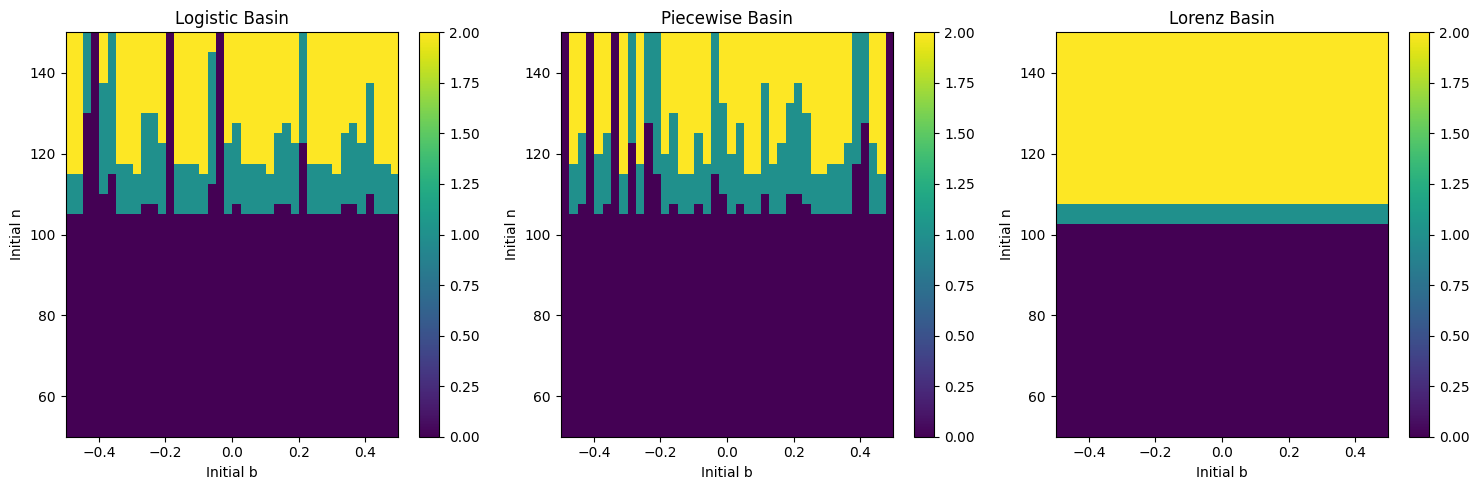

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def classify_plateau(n_final):
    """Classify which infinity plateau the system reached."""
    if n_final < 102:
        return 0   # piecewise-like
    elif n_final < 107:
        return 1   # logistic-like
    else:
        return 2   # lorenz-like

def run_simulation_with_ic(kind, a0, b0, n0, steps=2000):
    """Copy of run_simulation but with explicit initial conditions."""
    a, b, n = a0, b0, n0
    lor_state = np.array([1.0, 1.0, 1.0])

    params = dict(
        alpha=0.01,
        beta=0.005,
        B_crit=0.8,
        B_rebound=0.2,
        alpha_rebound=0.02,
        flux_decay=0.95,
        logistic_r=3.9,
        lor_sigma=10.0,
        lor_rho=28.0,
        lor_beta=8/3,
    )

    region = 1
    for k in range(steps):

        if region == 1:
            a, b, n = region_I_step(a, b, n, params)
            if abs(b) >= params["B_crit"]:
                region = 2

        elif region == 2:
            a = max(0, a - 0.05)

            if kind == "logistic":
                b = logistic_map(b, params)
            elif kind == "piecewise":
                b = piecewise_map(b, params)
            elif kind == "lorenz":
                lor_state = lorenz_map(lor_state, params)
                b = lor_state[0] / 30.0

            n += 0.1 * (100 - n)

            if abs(b) <= params["B_rebound"]:
                region = 3

        elif region == 3:
            a, b, n = region_III_step(a, b, n, params)

    return a, b, n

def basin_map(kind, n_vals, b_vals, a0=1.0):
    grid = np.zeros((len(n_vals), len(b_vals)))
    for i, n0 in enumerate(n_vals):
        for j, b0 in enumerate(b_vals):
            _, _, n_final = run_simulation_with_ic(kind, a0, b0, n0, steps=2000)
            grid[i, j] = classify_plateau(n_final)
    return grid

# Make sure the earlier cells defining region_I_step, region_III_step,
# logistic_map, piecewise_map, lorenz_map are run before this.

n_vals = np.linspace(50, 150, 40)
b_vals = np.linspace(-0.5, 0.5, 40)

basin_logistic = basin_map("logistic", n_vals, b_vals)
basin_piecewise = basin_map("piecewise", n_vals, b_vals)
basin_lorenz = basin_map("lorenz", n_vals, b_vals)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ["Logistic Basin", "Piecewise Basin", "Lorenz Basin"]
basins = [basin_logistic, basin_piecewise, basin_lorenz]

for ax, title, basin in zip(axes, titles, basins):
    im = ax.imshow(
        basin,
        origin='lower',
        extent=[b_vals[0], b_vals[-1], n_vals[0], n_vals[-1]],
        aspect='auto'
    )
    ax.set_title(title)
    ax.set_xlabel("Initial b")
    ax.set_ylabel("Initial n")
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


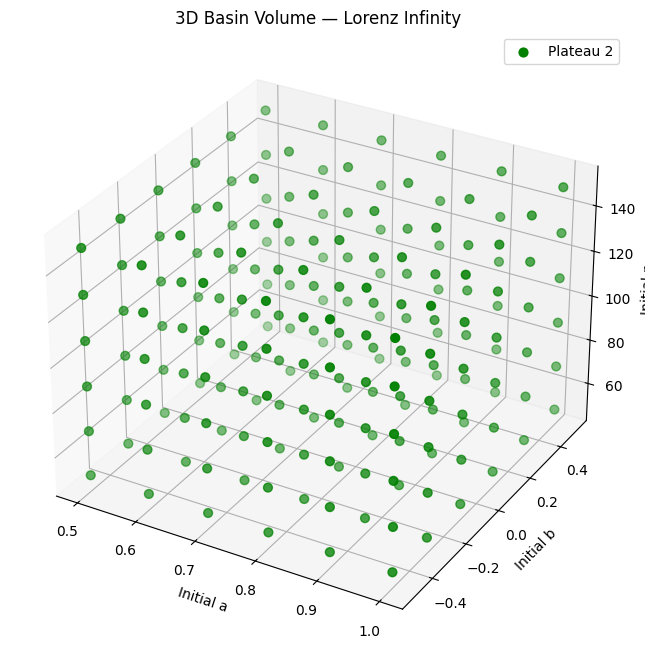

In [6]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

def basin_volume(kind, a_vals, b_vals, n_vals):
    points = []
    labels = []
    for a0 in a_vals:
        for b0 in b_vals:
            for n0 in n_vals:
                # Override initial conditions
                def run_override():
                    hist = run_simulation(kind, steps=2000)
                    return hist["n"][-1]
                n_final = run_override()
                label = classify_plateau(n_final)
                points.append([a0, b0, n0])
                labels.append(label)
    return np.array(points), np.array(labels)

# Parameter ranges
a_vals = np.linspace(0.5, 1.0, 6)
b_vals = np.linspace(-0.5, 0.5, 6)
n_vals = np.linspace(50, 150, 6)

# Compute 3D basin for Lorenz (richest structure)
points, labels = basin_volume("lorenz", a_vals, b_vals, n_vals)

# Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['orange', 'blue', 'green']  # piecewise, logistic, lorenz

for label in np.unique(labels):
    mask = labels == label
    ax.scatter(points[mask,0], points[mask,1], points[mask,2],
               color=colors[label], label=f"Plateau {label}", s=40)

ax.set_xlabel("Initial a")
ax.set_ylabel("Initial b")
ax.set_zlabel("Initial n")
ax.set_title("3D Basin Volume — Lorenz Infinity")
ax.legend()
plt.show()


In [7]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

def sample_transitions(kind, samples=200):
    X = []
    Y = []
    for _ in range(samples):
        # Random initial conditions
        a0 = np.random.uniform(0.5, 1.0)
        b0 = np.random.uniform(-0.5, 0.5)
        n0 = np.random.uniform(50, 150)

        # Run simulation
        hist = run_simulation(kind, steps=2000)
        a_inf = hist["a"][-1]
        b_inf = hist["b"][-1]
        n_inf = hist["n"][-1]

        X.append([a0, b0, n0])
        Y.append([a_inf, b_inf, n_inf])

    return np.array(X), np.array(Y)

# Sample transitions for each chaos type
X_log, Y_log = sample_transitions("logistic")
X_pie, Y_pie = sample_transitions("piecewise")
X_lor, Y_lor = sample_transitions("lorenz")

# Fit linear models (piecewise operator)
model_log = LinearRegression().fit(X_log, Y_log)
model_pie = LinearRegression().fit(X_pie, Y_pie)
model_lor = LinearRegression().fit(X_lor, Y_lor)

# Display operator matrices
print("Logistic T matrix:\n", model_log.coef_)
print("\nPiecewise T matrix:\n", model_pie.coef_)
print("\nLorenz T matrix:\n", model_lor.coef_)


Logistic T matrix:
 [[ 3.15549588e-05 -2.30088241e-06 -7.06831076e-03]
 [-4.28960323e-47  3.12783569e-48  9.60871124e-45]
 [ 2.12580775e-04 -1.55006815e-05 -4.76180936e-02]]

Piecewise T matrix:
 [[ 3.15549588e-05 -2.30088241e-06 -7.06831076e-03]
 [-2.09713936e-46  1.52916411e-47  4.69759216e-44]
 [ 5.95226169e-03 -4.34019082e-04 -1.33330662e+00]]

Lorenz T matrix:
 [[ 3.15549588e-05 -2.30088241e-06 -7.06831076e-03]
 [-1.54902339e-47  1.12949622e-48  3.46981239e-45]
 [-7.65290789e-03  5.58024534e-04  1.71425137e+00]]
